# Preprocessing Satria Data

In [9]:
import pandas as pd

df = pd.read_csv('../data/Data Problem Kedua.csv')
df.shape

(1000, 3)

In [10]:
df.head()

,Id,Video,Emotion
0,1,https://drive.google.com/file/d/1uJrAub9Ht_4X_...,Trust
1,2,https://drive.google.com/file/d/1zM_ds6y4N-22v...,Proud
2,3,https://drive.google.com/file/d/18LgEBVLPh6xc5...,Trust
3,4,https://drive.google.com/file/d/1dyMYKBLHBfuAv...,Surprise
4,5,https://drive.google.com/file/d/1bMMUhXgigGbM5...,Proud


# Fix Label Data

In [11]:
def map_emotions(df, emotion_column):
    # Mapping variasi label ke label utama
    emotion_map = {
        # Proud
        'Proud': 'Proud', 'Bangga': 'Proud',
        # Trust
        'Trust': 'Trust', 'Loyalty': 'Trust', 'Faith': 'Trust', 'Percaya': 'Trust',
        # Joy
        'Joy': 'Joy', 'Love': 'Joy',
        # Surprise
        'Surprise': 'Surprise', 'Terkejut': 'Surprise', 'Trkejut': 'Surprise', 'Terkjut': 'Surprise', 'Trekejut': 'Surprise', 'terkejut': 'Surprise', 'Kaget': 'Surprise', 'kaget': 'Surprise',
        # Neutral
        'Neutral': 'Neutral',
        # Sadness
        'Sadness': 'Sadness', 'Sad': 'Sadness',
        # Fear
        'Fear': 'Fear',
        # Anger
        'Anger': 'Anger', 'Marah': 'Anger', 'Marh': 'Anger',
    }

    # Mapping label utama ke angka
    label2num = {
        'Proud': 0,
        'Trust': 1,
        'Joy': 2,
        'Surprise': 3,
        'Neutral': 4,
        'Sadness': 5,
        'Fear': 6,
        'Anger': 7,
    }

    # Bersihkan dan mapping label
    df['emotion_clean'] = df[emotion_column].map(emotion_map)
    df['emotion_label'] = df['emotion_clean'].map(label2num)

    # Return dataframe dengan kolom baru
    return df

In [12]:
df = map_emotions(df, 'Emotion')
df.head()

,Id,Video,Emotion,emotion_clean,emotion_label
0,1,https://drive.google.com/file/d/1uJrAub9Ht_4X_...,Trust,Trust,1
1,2,https://drive.google.com/file/d/1zM_ds6y4N-22v...,Proud,Proud,0
2,3,https://drive.google.com/file/d/18LgEBVLPh6xc5...,Trust,Trust,1
3,4,https://drive.google.com/file/d/1dyMYKBLHBfuAv...,Surprise,Surprise,3
4,5,https://drive.google.com/file/d/1bMMUhXgigGbM5...,Proud,Proud,0


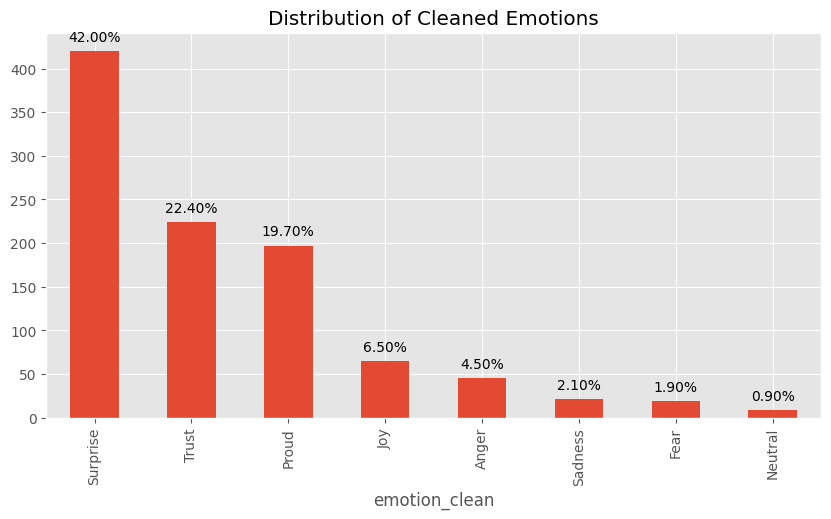

In [6]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')

# Plot bar chart
ax = df['emotion_clean'].value_counts().plot(kind='bar', figsize=(10, 5), title='Distribution of Cleaned Emotions')

# Tambahkan persentase pada setiap batang
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

# Get Video file from link

In [7]:
# cek df 'video' yang duplicated
df[df.duplicated(subset=['Video'], keep=False)].sort_values(by='Video').shape[0]

93

Download file 

In [9]:
# --- Download Instagram Reels Videos from 'video' column using yt-dlp ---
# Install yt-dlp jika belum ada
try:
    import yt_dlp
except ImportError:
    import sys
    !{sys.executable} -m pip install yt-dlp
    import yt_dlp

In [10]:
def download_instagram_video(url, save_dir, filename=None):
    os.makedirs(save_dir, exist_ok=True)

    # kalau ada versi mp4 <=480p, ambil itu dulu (minim re-encode)
    format_selector = "mp4[height<=480]/best[ext=mp4]/best"

    outtmpl = os.path.join(save_dir, '%(id)s.%(ext)s') if filename is None \
              else os.path.join(save_dir, filename if filename.endswith('.mp4') else f"{filename}.mp4")

    ydl_opts = {
        'outtmpl': outtmpl,
        'quiet': True,
        'noplaylist': True,
        'format': format_selector,

        'cookiesfrombrowser': ('firefox',),

        # Paksa transcode H.264/AAC + CRF kalau sumbernya di atas target atau bukan mp4
        'postprocessor_args': [
            # Video
            '-c:v', 'libx264',
            '-crf', '27',          # 26–28: makin besar = makin kecil
            '-preset', 'medium',   # 'slow' kalau CPU santai
            '-pix_fmt', 'yuv420p',
            '-vf', 'scale=-2:360,fps=10',  # 360p @ 10fps
            '-movflags', '+faststart',

            # Audio
            '-c:a', 'aac',
            '-b:a', '64k',
            '-ac', '1',
            '-ar', '16000',
        ],
        'merge_output_format': 'mp4',
        'retries': 3,
    }

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        try:
            info = ydl.extract_info(url, download=True)
            # normalisasi ekstensi
            out_path = outtmpl
            if '%(id)s' in outtmpl:
                vid_id = info.get('id', 'video')
                out_path = outtmpl.replace('%(id)s', vid_id).replace('%(ext)s', 'mp4')
            return out_path
        except Exception as e:
            print(f"Failed to download {url}: {e}")
            return None


In [11]:
import os
import yt_dlp

def download_instagram_video(url, save_dir, filename=None):
    os.makedirs(save_dir, exist_ok=True)

    # ambil mp4 serendah mungkin dulu biar minim kerjaan re-encode
    format_selector = "mp4[height<=480]/best[ext=mp4]/best"

    outtmpl = (
        os.path.join(save_dir, '%(id)s.%(ext)s')
        if filename is None
        else os.path.join(save_dir, filename if filename.endswith('.mp4') else f"{filename}.mp4")
    )

    ydl_opts = {
        "outtmpl": outtmpl,
        "quiet": True,
        "noplaylist": True,
        "format": format_selector,

        # Instagram sering butuh cookie/login
        "cookiesfrombrowser": ("firefox",),  # ganti profil bila perlu, contoh: ("firefox", "default", None, None)

        # --- KUNCI: paksa re-encode agar -vf/fps/bitrate beneran diterapkan ---
        "recode_video": "mp4",  # trigger FFmpegVideoConvertor

        # Terapkan argumen spesifik per postprocessor agar -vf tidak dibawa ke merger
        "postprocessor_args": {
            # untuk convert video (baru di sini -vf & codec video dipakai)
            "FFmpegVideoConvertor": [
                "-c:v", "libx264",
                "-crf", "27",            # 26–28 makin kecil size
                "-preset", "medium",     # "slow" kalau CPU santai
                "-pix_fmt", "yuv420p",
                "-vf", "scale=-2:360,fps=10",  # 360p @ 10fps
                "-movflags", "+faststart",
            ],
            # untuk convert audio (kalau ada)
            "FFmpegAudioConvertor": [
                "-c:a", "aac",
                "-b:a", "64k",
                "-ac", "1",
                "-ar", "16000",
            ],
        },

        # kalau pernah nyatuin audio+video terpisah
        "merge_output_format": "mp4",

        # robustness
        "retries": 3,
        "fragment_retries": 3,
        "ratelimit": None,  # bisa di-set misal 1.5M untuk koneksi labil
        "ignoreerrors": "only_download",  # lanjut walau satu item gagal
    }

    try:
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            info = ydl.extract_info(url, download=True)
            # normalisasi path output
            out_path = outtmpl
            if "%(id)s" in outtmpl:
                vid_id = info.get("id", "video")
                out_path = outtmpl.replace("%(id)s", vid_id).replace("%(ext)s", "mp4")
            return out_path
    except Exception as e:
        print(f"Failed to download {url}: {e}")
        return None


In [ ]:
import pandas as pd
from tqdm.auto import tqdm
import os
import glob

def _find_existing_video(target_dir, video_id, preferred_ext=".mp4", other_exts=(".mp4", ".m4v", ".mov", ".webm", ".mkv")):
    """
    Cari file video yang sudah ada berdasarkan video_id di folder target_dir.
    Prioritaskan ekstensi preferred_ext, kalau tidak ada cek pilihan lainnya.
    Return: path file jika ada, else None.
    """
    # Prioritaskan nama yang diharapkan (mis. .mp4)
    expected_path = os.path.join(target_dir, f"{video_id}{preferred_ext}")
    if os.path.exists(expected_path):
        return expected_path

    # Cek ekstensi lain yang mungkin
    for ext in other_exts:
        p = os.path.join(target_dir, f"{video_id}{ext}")
        if os.path.exists(p):
            return p

    # Fallback: kalau ada file yang mengandung video_id (mis. nama disesuaikan downloader)
    pattern = os.path.join(target_dir, f"*{video_id}*")
    matches = sorted(glob.glob(pattern))
    for p in matches:
        if os.path.isfile(p):
            return p

    return None


def batch_download_videos(df, url_col, save_dir, id_col='Id', label_col=None, path_col='video_path'):
    """
    Mengunduh video dari DataFrame dan melewati yang sudah ada.
    - Jika `label_col` diberikan, video disimpan dalam subfolder sesuai label.
    - Jika `label_col` adalah None, video disimpan langsung di `save_dir`.
    - Jika nilai di `path_col` sudah ada (bukan NaN) dan file-nya ada, baris tsb dilewati.
    - Jika file dengan Id yang sama sudah ada di folder tujuan, isi `video_path` dan lewati download.
    """
    paths = []
    os.makedirs(save_dir, exist_ok=True)
    
    # Pastikan kolom path ada
    if path_col not in df.columns:
        df[path_col] = pd.NA

    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Downloading videos to {save_dir}"):
        # 1) Jika sudah ada path & file-nya benar-benar ada -> pakai dan lanjut
        if pd.notna(row[path_col]) and isinstance(row[path_col], str) and os.path.exists(row[path_col]):
            paths.append(row[path_col])
            continue

        # 2) Ambil basic info
        url = row.get(url_col, None)
        video_id = row.get(id_col, None)

        # Validasi minimal
        if pd.isna(video_id) or video_id is None:
            paths.append(pd.NA)
            continue
        if pd.isna(url) or not isinstance(url, str) or not url.strip():
            # URL invalid: tapi tetap cek apakah file sudah ada berdasar Id (berguna kalau pernah diunduh manual)
            # Tentukan folder target dulu
            target_directory = save_dir
            if label_col:
                label = row.get(label_col, None)
                if pd.notna(label):
                    target_directory = os.path.join(save_dir, str(label))
            existing = _find_existing_video(target_directory, video_id)
            paths.append(existing if existing else pd.NA)
            continue

        # 3) Tentukan folder tujuan
        target_directory = save_dir
        if label_col:
            label = row.get(label_col, None)
            if pd.notna(label):
                target_directory = os.path.join(save_dir, str(label))
            else:
                # Konsisten dengan perilaku lama: jika label None/NaN saat label_col diberikan, skip
                # Namun tetap cek apakah file sudah ada di save_dir (barangkali diunduh sebelumnya)
                existing = _find_existing_video(save_dir, video_id)
                paths.append(existing if existing else pd.NA)
                continue

        # 4) Cek pre-existence berdasarkan Id di folder target
        existing = _find_existing_video(target_directory, video_id)
        if existing:
            paths.append(existing)
            continue

        # 5) Kalau belum ada, siapkan nama file & download
        os.makedirs(target_directory, exist_ok=True)
        filename = f"{video_id}.mp4"

        # NOTE: asumsi fungsi ini sudah kamu definisikan di tempat lain
        video_path = download_instagram_video(url, target_directory, filename=filename)

        # 6) Kalau downloader mengembalikan None/ gagal, coba cek lagi apakah file akhirnya ada
        if not video_path:
            video_path = _find_existing_video(target_directory, video_id)

        paths.append(video_path if video_path else pd.NA)

    df[path_col] = paths
    return df


In [27]:
# penggunaan:
video_dir = '../data/raw/videos'

# Cukup jalankan lagi, fungsi akan otomatis tahu mana yang harus dikerjakan
df_metadata = batch_download_videos(df, 'Video', video_dir, label_col='Emotion')

In [23]:
df_metadata

,Id,Video,Emotion,video_path
109,110,https://drive.google.com/file/d/1u5RE2qDiN4Sbt...,Proud,<NA>
368,369,https://drive.google.com/file/d/1GZb1QrS9XT4ZG...,Surprise,<NA>


In [11]:
df_metadata.to_csv('../data/metadata_with_videos.csv', index=False)

In [ ]:
df_metadata.head()

In [13]:
df_metadata = pd.read_csv('../data/metadata_with_videos.csv', index_col=0)
df_metadata.query("video_path.notna()").shape

(1000, 5)

# Ekstrak Audio

In [2]:
import os
import subprocess
from glob import glob
from tqdm.auto import tqdm

def extract_audio_ffmpeg(video_path, audio_path, sr=16000):
    os.makedirs(os.path.dirname(audio_path), exist_ok=True)
    cmd = [
        "ffmpeg", "-y", "-i", video_path,
        "-vn", "-acodec", "pcm_s16le", "-ar", str(sr), "-ac", "1", audio_path
    ]
    try:
        subprocess.run(cmd, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        return True
    except subprocess.CalledProcessError as e:
        print(f"Gagal ekstrak audio dari {video_path}: {e}")
        return False

video_dir_train = "../data/raw/videos"
audio_dir = "../data/raw/audios"
label_folders = [f for f in glob(os.path.join(video_dir_train, "*")) if os.path.isdir(f)]
for label_folder in tqdm(label_folders, desc="Transform Audio"):
    label = os.path.basename(label_folder)
    video_files = glob(os.path.join(label_folder, "*.mp4"))
    for v in tqdm(video_files, desc=f"{label}", leave=False):
        vid = os.path.splitext(os.path.basename(v))[0]
        out_audio = os.path.join(audio_dir, label, f"{vid}.wav")
        extract_audio_ffmpeg(v, out_audio)


Transform Audio:   0%|          | 0/8 [00:00<?, ?it/s]

Anger:   0%|          | 0/45 [00:00<?, ?it/s]

Fear:   0%|          | 0/19 [00:00<?, ?it/s]

Joy:   0%|          | 0/65 [00:00<?, ?it/s]

Neutral:   0%|          | 0/9 [00:00<?, ?it/s]

Proud:   0%|          | 0/196 [00:00<?, ?it/s]

Sadness:   0%|          | 0/21 [00:00<?, ?it/s]

Surprise:   0%|          | 0/419 [00:00<?, ?it/s]

Trust:   0%|          | 0/224 [00:00<?, ?it/s]